In [2012]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import lightgbm as lgb
from dateutil.parser import parse
from datetime import datetime
from sklearn.impute import SimpleImputer
from sklearn.base import TransformerMixin,BaseEstimator
from bayes_opt import BayesianOptimization
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn import metrics
from lightgbm import plot_importance
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss

In [2013]:
data_train = pd.read_csv("C:/Users/zhouz/Desktop/python_project/train.csv")
data_test = pd.read_csv("C:/Users/zhouz/Desktop/python_project/test.csv")
pd.set_option('display.max_columns', None)

In [2014]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 47 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  800000 non-null  int64  
 1   loanAmnt            800000 non-null  float64
 2   term                800000 non-null  int64  
 3   interestRate        800000 non-null  float64
 4   installment         800000 non-null  float64
 5   grade               800000 non-null  object 
 6   subGrade            800000 non-null  object 
 7   employmentTitle     799999 non-null  float64
 8   employmentLength    753201 non-null  object 
 9   homeOwnership       800000 non-null  int64  
 10  annualIncome        800000 non-null  float64
 11  verificationStatus  800000 non-null  int64  
 12  issueDate           800000 non-null  object 
 13  isDefault           800000 non-null  int64  
 14  purpose             800000 non-null  int64  
 15  postCode            799999 non-nul

In [2015]:
cols = ["id","homeOwnership","verificationStatus","purpose","regionCode","initialListStatus","applicationType",\
        "employmentTitle","postCode","title","policyCode"]
for col in cols:
    data_train[col] = data_train[col].astype(str)    

In [2016]:
data_train.describe()

,loanAmnt,term,interestRate,installment,annualIncome,isDefault,dti,delinquency_2years,ficoRangeLow,ficoRangeHigh,openAcc,pubRec,pubRecBankruptcies,revolBal,revolUtil,totalAcc,n0,n1,n2,n3,n4,n5,n6,n7,n8,n9,n10,n11,n12,n13,n14
count,800000.000000,800000.000000,800000.000000,800000.000000,8.000000e+05,800000.000000,799761.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,799595.000000,8.000000e+05,799469.000000,800000.000000,759730.000000,759730.000000,759730.000000,759730.000000,766761.000000,759730.000000,759730.000000,759730.000000,759729.000000,759730.000000,766761.000000,730248.000000,759730.000000,759730.000000,759730.000000
mean,14416.818875,3.482745,13.238391,437.947723,7.613391e+04,0.199513,18.284557,0.318239,696.204081,700.204226,11.598020,0.214915,0.134163,1.622871e+04,51.790734,24.998861,0.511932,3.642330,5.642648,5.642648,4.735641,8.107937,8.575994,8.282953,14.622488,5.592345,11.643896,0.000815,0.003384,0.089366,2.178606
std,8716.086178,0.855832,4.765757,261.460393,6.894751e+04,0.399634,11.150155,0.880325,31.865995,31.866674,5.475286,0.606467,0.377471,2.245802e+04,24.516126,11.999201,1.333266,2.246825,3.302810,3.302810,2.949969,4.799210,7.400536,4.561689,8.124610,3.216184,5.484104,0.030075,0.062041,0.509069,1.844377
min,500.000000,3.000000,5.310000,15.690000,0.000000e+00,0.000000,-1.000000,0.000000,630.000000,634.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8000.000000,3.000000,9.750000,248.450000,4.560000e+04,0.000000,11.790000,0.000000,670.000000,674.000000,8.000000,0.000000,0.000000,5.944000e+03,33.400000,16.000000,0.000000,2.000000,3.000000,3.000000,3.000000,5.000000,4.000000,5.000000,9.000000,3.000000,8.000000,0.000000,0.000000,0.000000,1.000000
50%,12000.000000,3.000000,12.740000,375.135000,6.500000e+04,0.000000,17.610000,0.000000,690.000000,694.000000,11.000000,0.000000,0.000000,1.113200e+04,52.100000,23.000000,0.000000,3.000000,5.000000,5.000000,4.000000,7.000000,7.000000,7.000000,13.000000,5.000000,11.000000,0.000000,0.000000,0.000000,2.000000
75%,20000.000000,3.000000,15.990000,580.710000,9.000000e+04,0.000000,24.060000,0.000000,710.000000,714.000000,14.000000,0.000000,0.000000,1.973400e+04,70.700000,32.000000,0.000000,5.000000,7.000000,7.000000,6.000000,11.000000,11.000000,10.000000,19.000000,7.000000,14.000000,0.000000,0.000000,0.000000,3.000000
max,40000.000000,5.000000,30.990000,1715.420000,1.099920e+07,1.000000,999.000000,39.000000,845.000000,850.000000,86.000000,86.000000,12.000000,2.904836e+06,892.300000,162.000000,51.000000,33.000000,63.000000,63.000000,49.000000,70.000000,132.000000,79.000000,128.000000,45.000000,82.000000,4.000000,4.000000,39.000000,30.000000


In [2017]:
numerical_fea = list(data_train.select_dtypes(exclude = ['object']).columns)
category_fea = list(filter(lambda x: x not in numerical_fea,data_train.columns))

In [2018]:
def get_numerical_serial_fea(data,feas):
    numerical_serial_fea = []
    numerical_noserial_fea = []
    for fea in feas:
        temp = data[fea].nunique()
        if temp <= 10:
            numerical_noserial_fea.append(fea)
            continue
        numerical_serial_fea.append(fea)
    return numerical_serial_fea,numerical_noserial_fea
numerical_serial_fea,numerical_noserial_fea = get_numerical_serial_fea(data_train,numerical_fea)

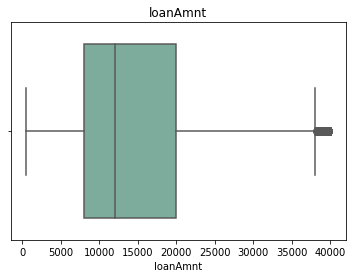

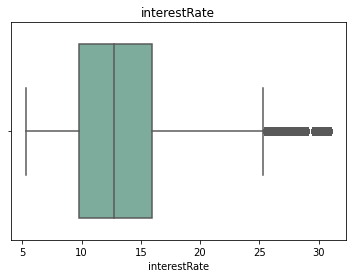

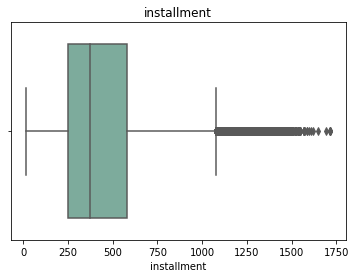

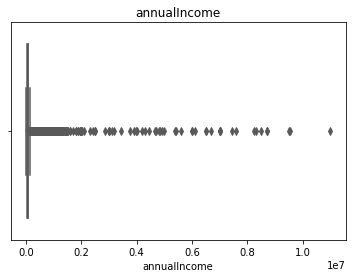

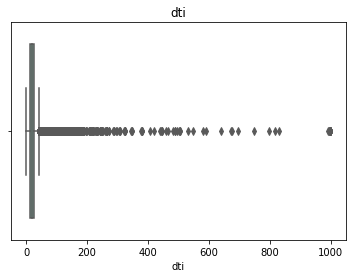

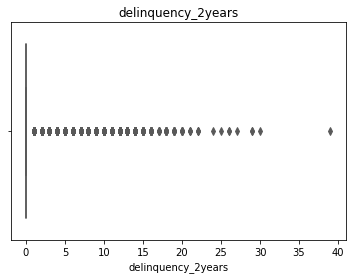

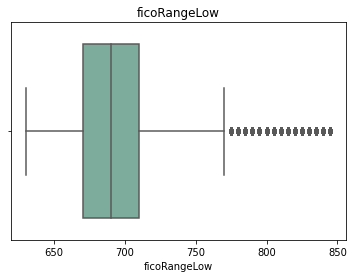

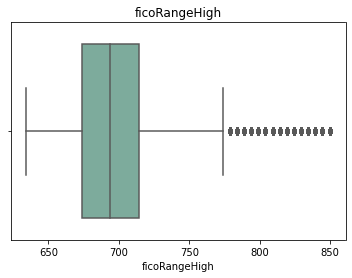

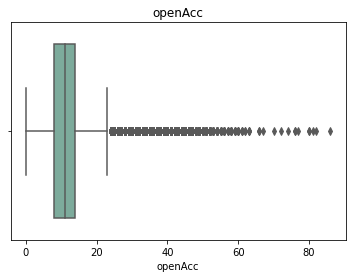

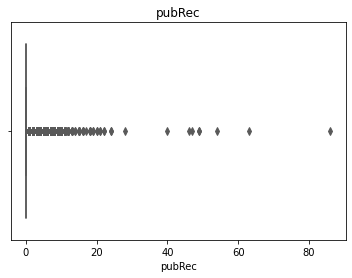

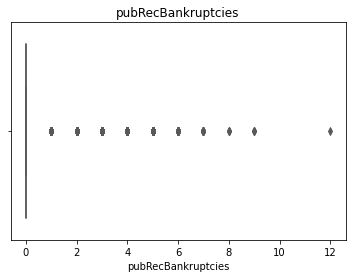

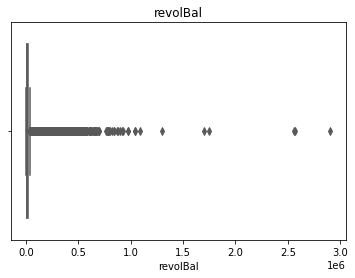

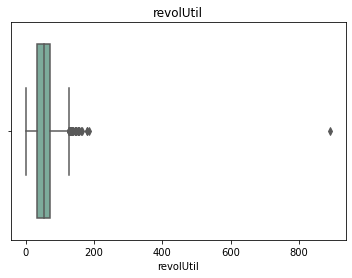

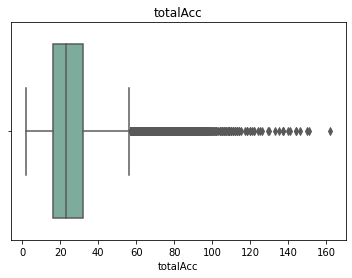

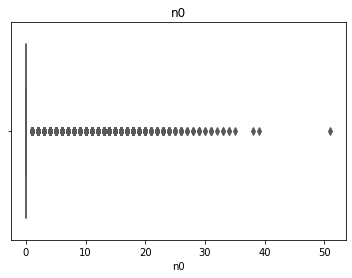

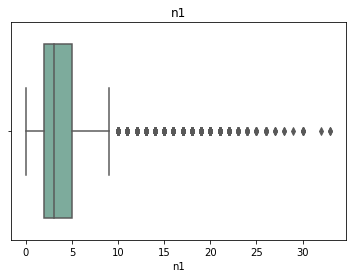

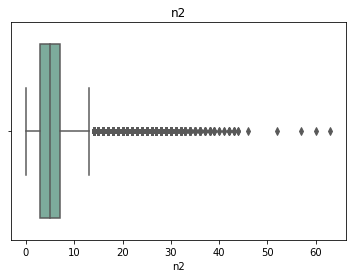

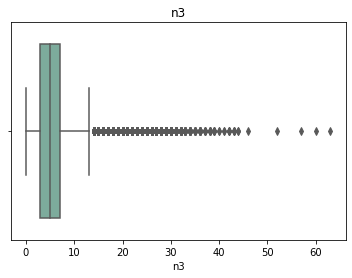

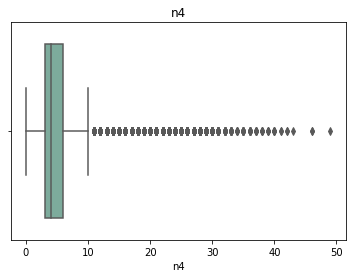

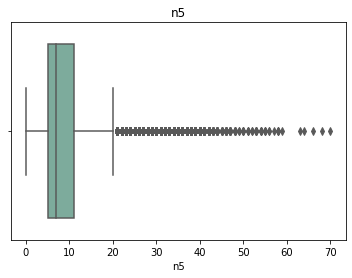

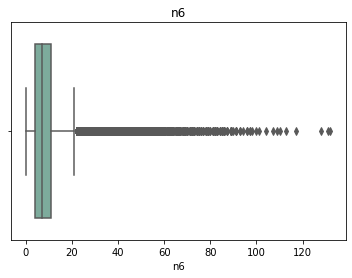

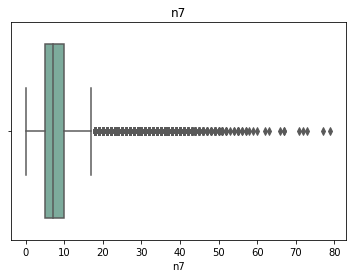

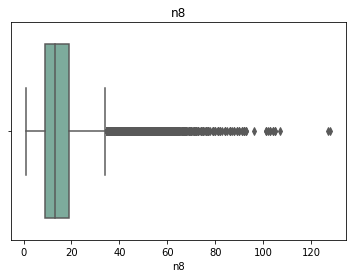

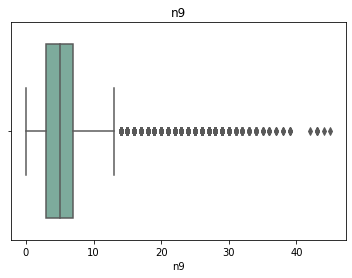

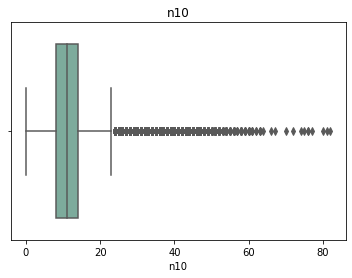

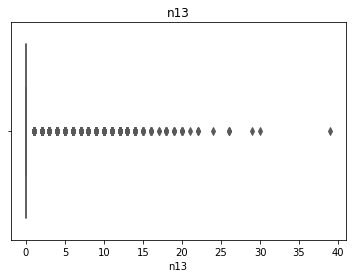

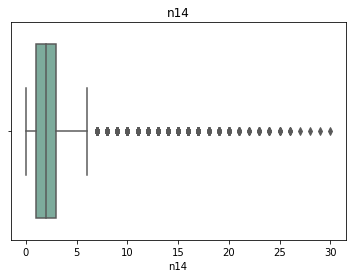

In [2019]:
for col in numerical_serial_fea:
    sns.boxplot(col,saturation = 0.5, palette = 'Set2',data = data_train)
    plt.title(col)
    plt.show()

In [2020]:

data_train = data_train.copy()  
cols = list(filter(lambda x: x in  numerical_fea and x not in['term','isDefault'],data_train.columns))
for col in cols:
    q1 = data_train[col].quantile(0.25)
    q3 = data_train[col].quantile(0.75)
    iqr = q3-q1
    upper = q3+iqr*1.5
    lower = q1-iqr*1.5
    data_train[col]=data_train[col][(data_train[col]<=upper)&(data_train[col]>=lower)] 
# # 将正常的数据按数据框形式筛选出来，返回一个已用NaN替换掉异常值DataFrame

In [2021]:
data_train.isnull().sum()

id                         0
loanAmnt                4246
term                       0
interestRate           14803
installment            24992
grade                      0
subGrade                   0
employmentTitle            0
employmentLength       46799
homeOwnership              0
annualIncome           39014
verificationStatus         0
issueDate                  0
isDefault                  0
purpose                    0
postCode                   0
regionCode                 0
dti                     3504
delinquency_2years    154285
ficoRangeLow           27667
ficoRangeHigh          27667
openAcc                27439
pubRec                135235
pubRecBankruptcies     99924
revolBal               47355
revolUtil                578
totalAcc               13446
initialListStatus          0
applicationType            0
earliesCreditLine          0
title                      0
policyCode                 0
n0                    220573
n1                     56098
n2            

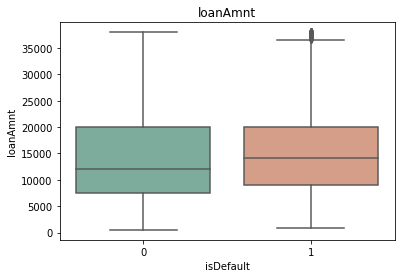

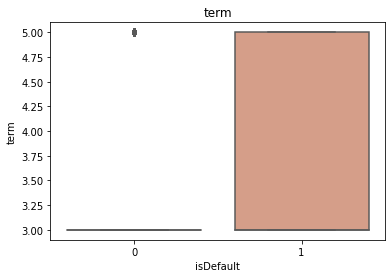

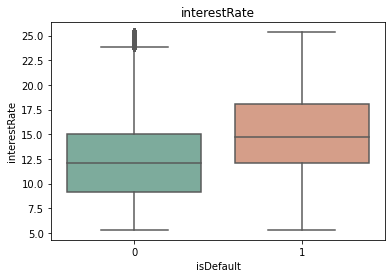

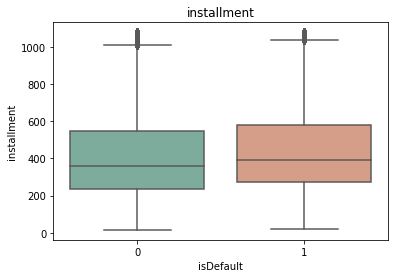

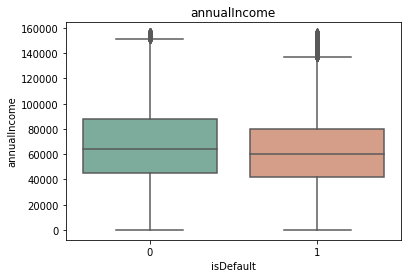

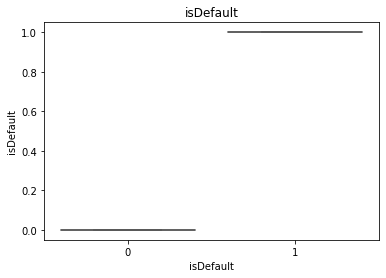

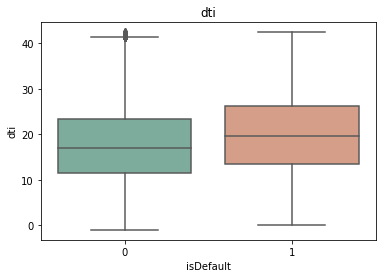

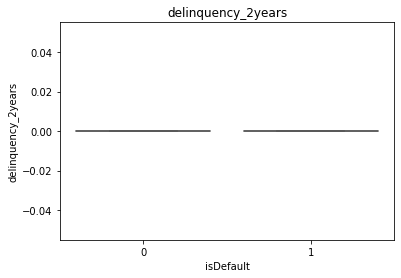

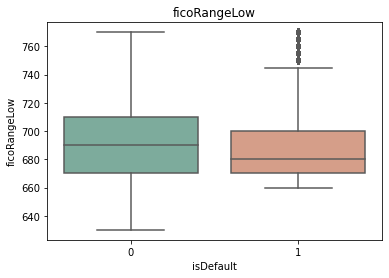

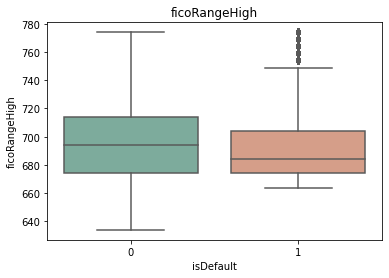

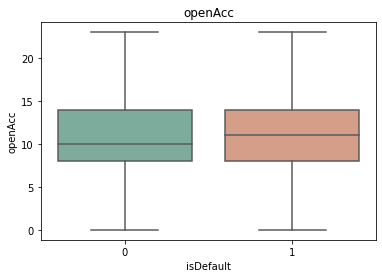

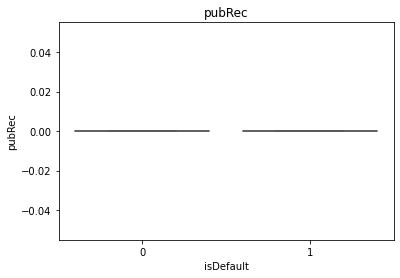

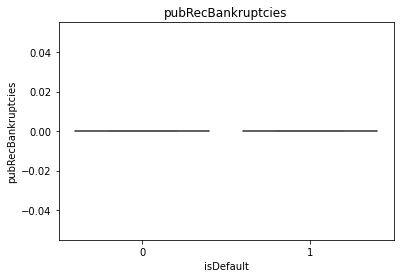

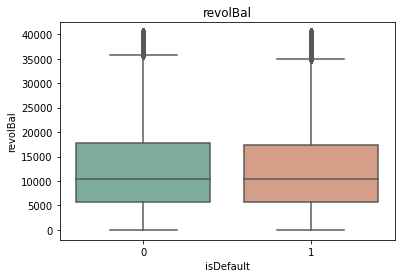

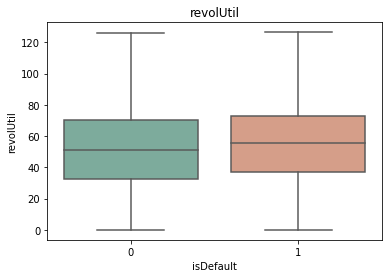

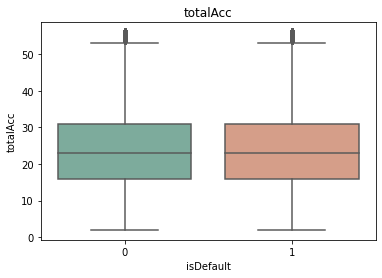

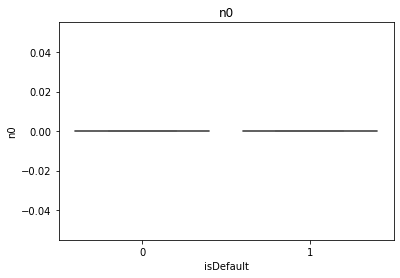

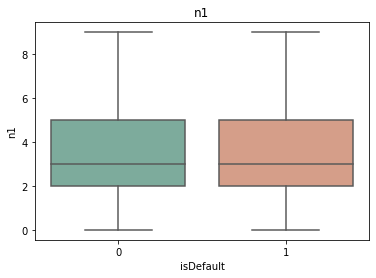

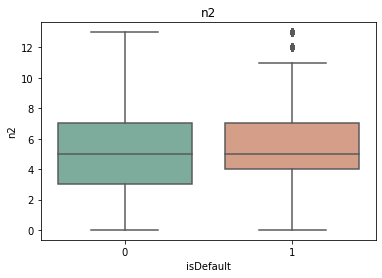

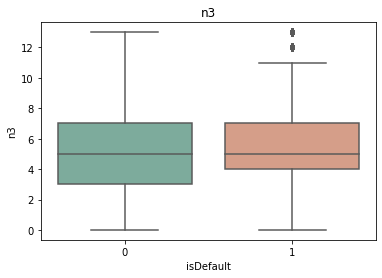

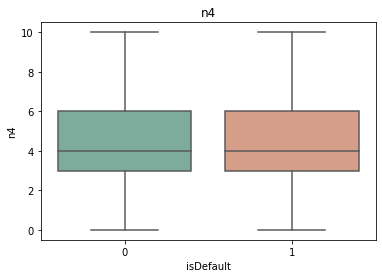

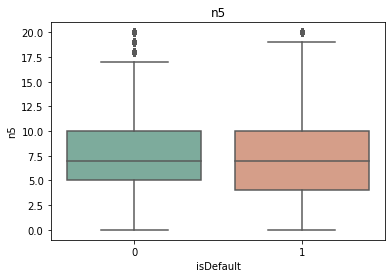

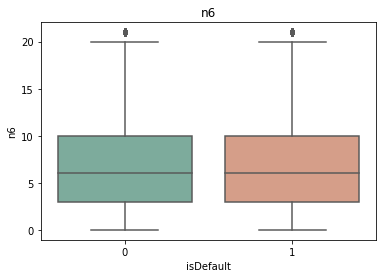

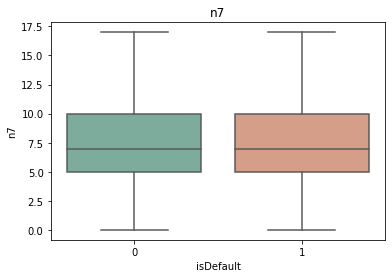

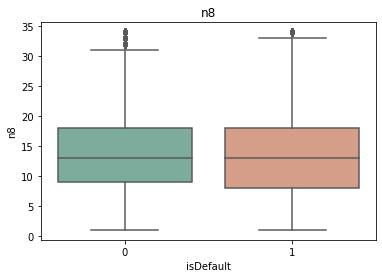

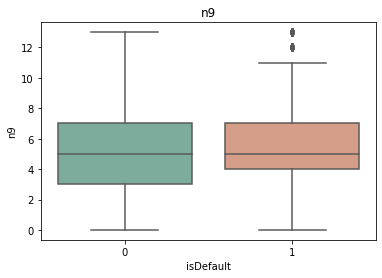

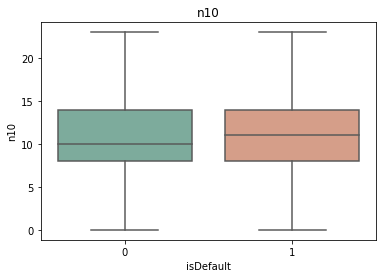

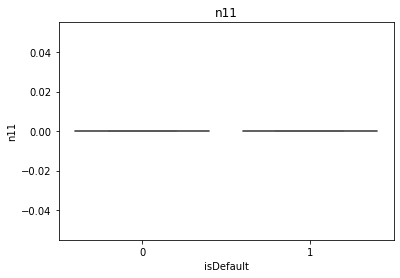

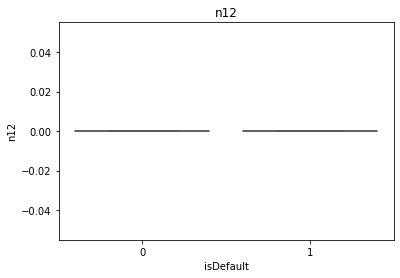

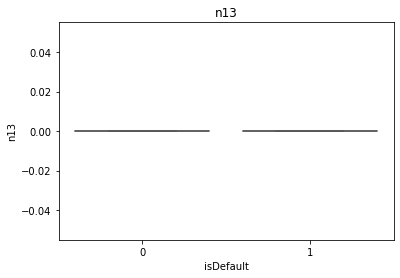

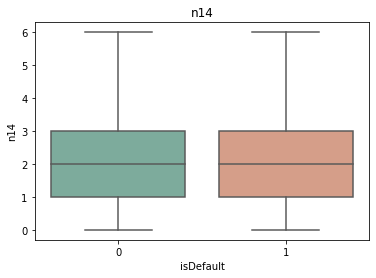

In [2022]:
for col in numerical_fea:
    sns.boxplot(x='isDefault',y = col ,saturation = 0.5, palette = 'Set2',data = data_train)
    plt.title(col)
    plt.show()

In [2023]:
def fea_bin(cols,bins):
    data = data_train.copy()
    for col in cols:
        data[col+'_bin']=pd.cut(data[col], bins=bins)
        sub_bin = data[col+'_bin'].value_counts(dropna=False).sort_index()
        sub_df = data.groupby([col+'_bin']).mean()
        fig,(ax1,ax2) = plt.subplots(ncols=2, figsize=(20,6))
        plt.suptitle('Fraud of {}'.format(col))
        sns.barplot(y=sub_bin.index, x=sub_bin,palette='pastel',ax=ax1)
        sns.barplot(y=sub_df.index, x=sub_df['isDefault'],palette='pastel',ax=ax2)

        plt.show()

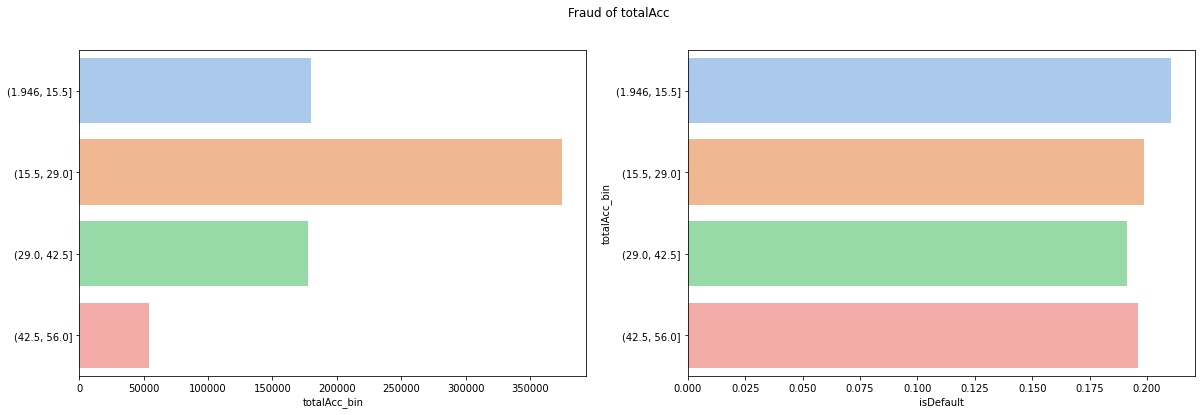

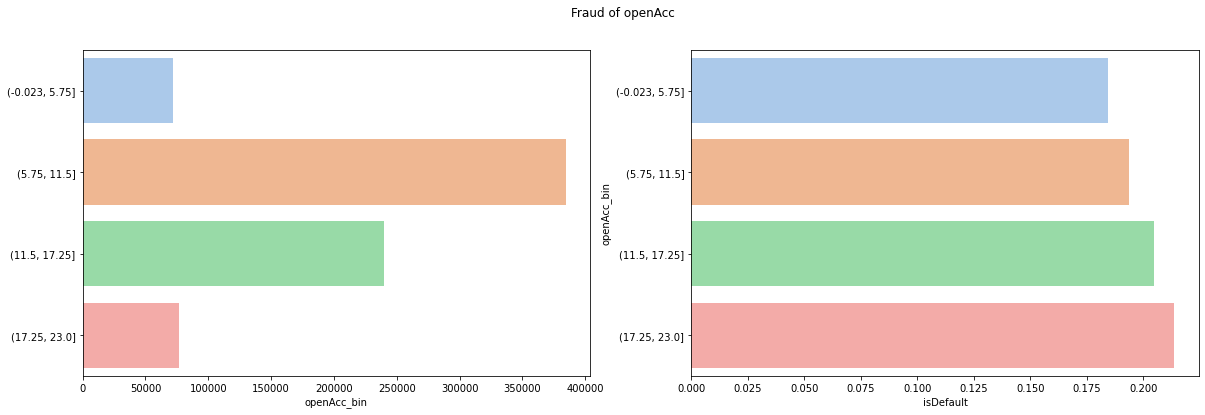

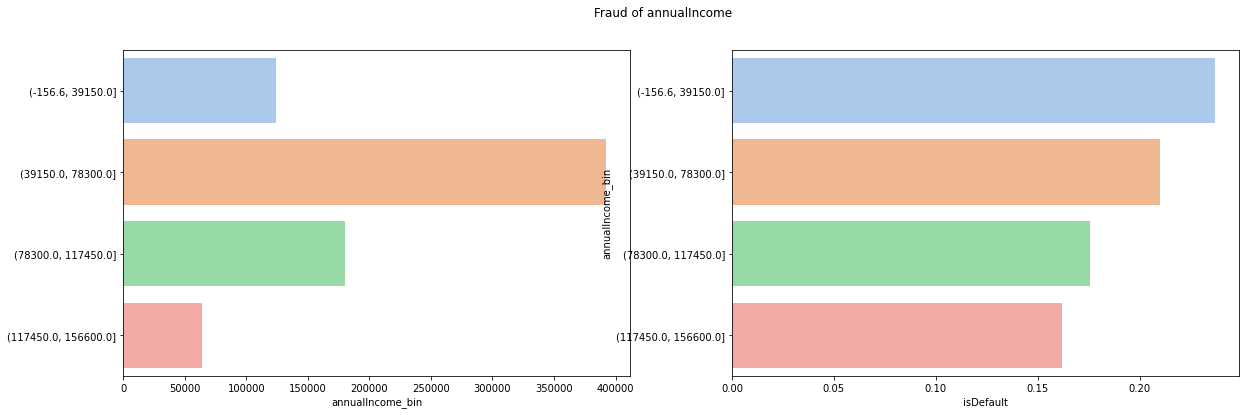

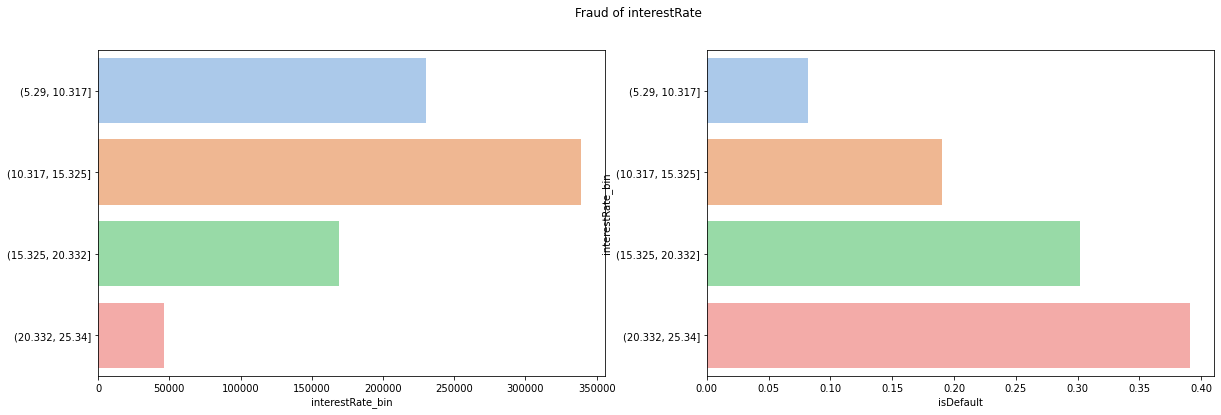

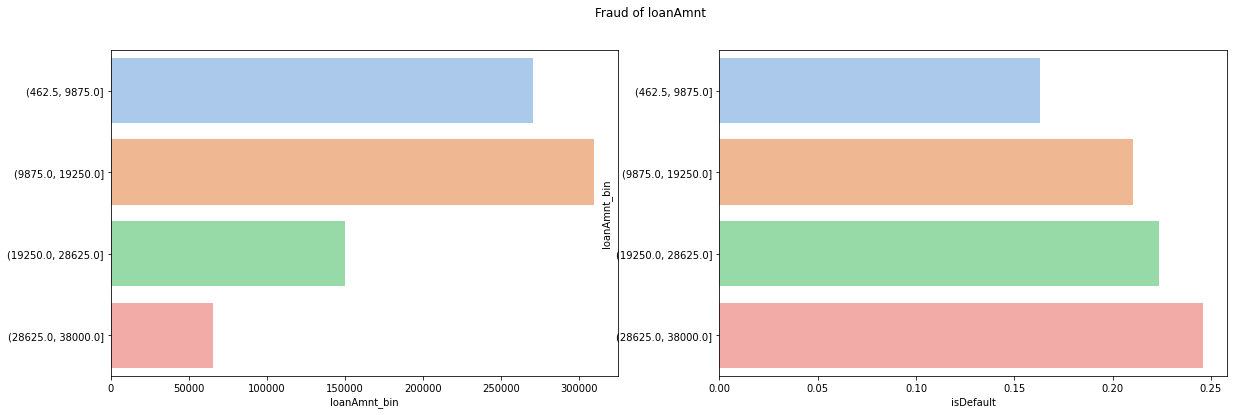

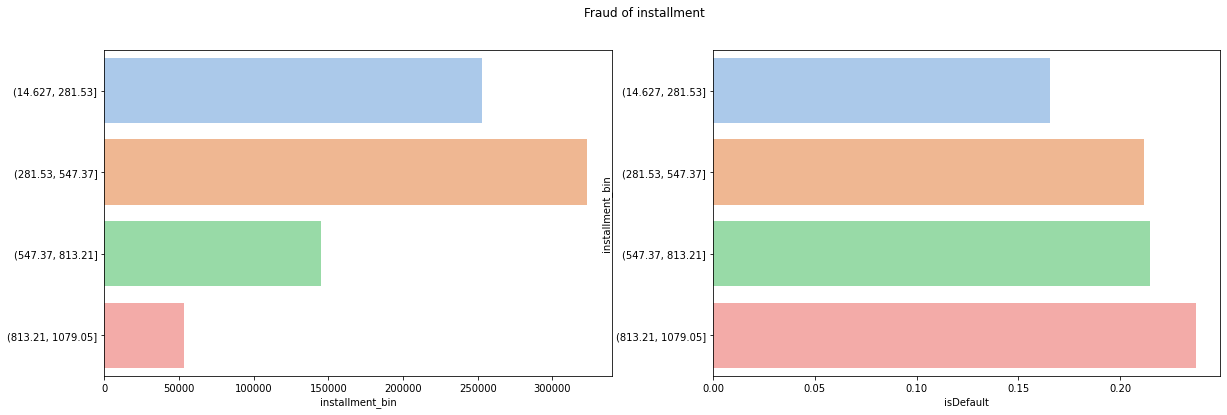

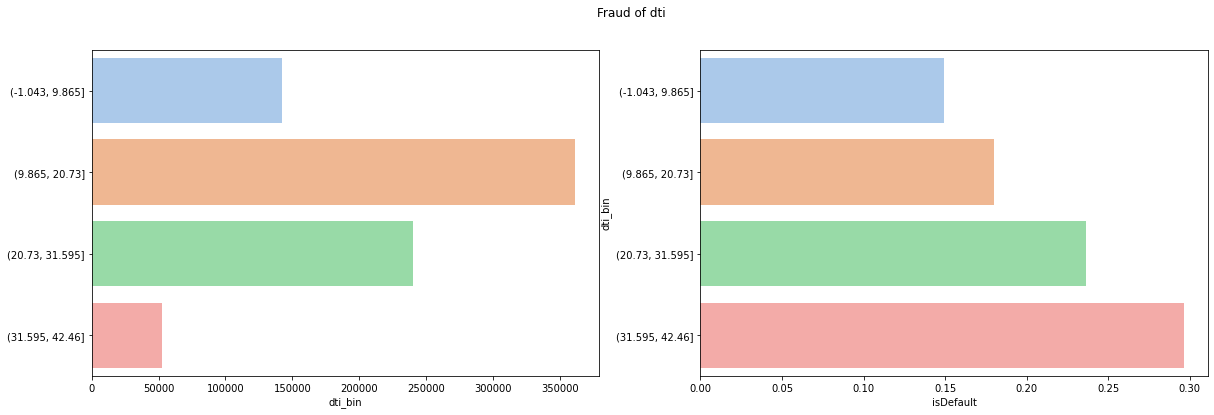

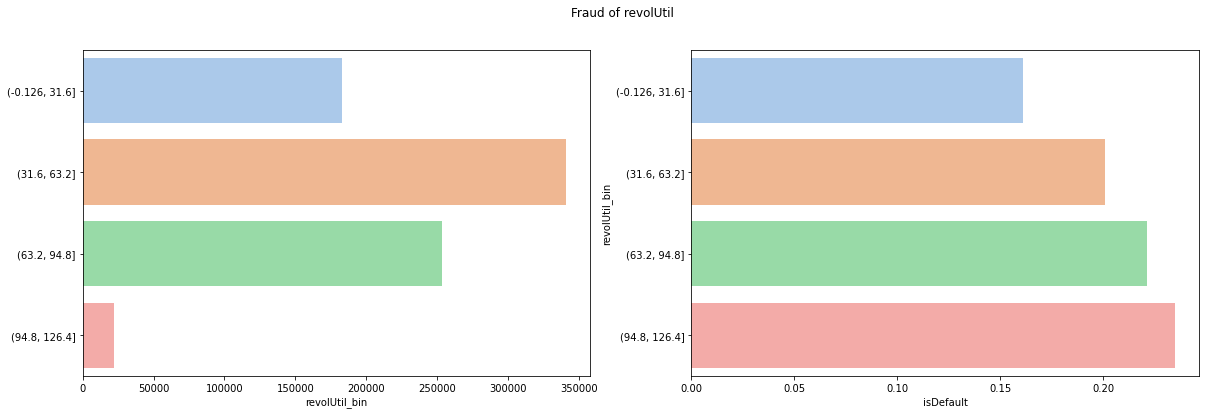

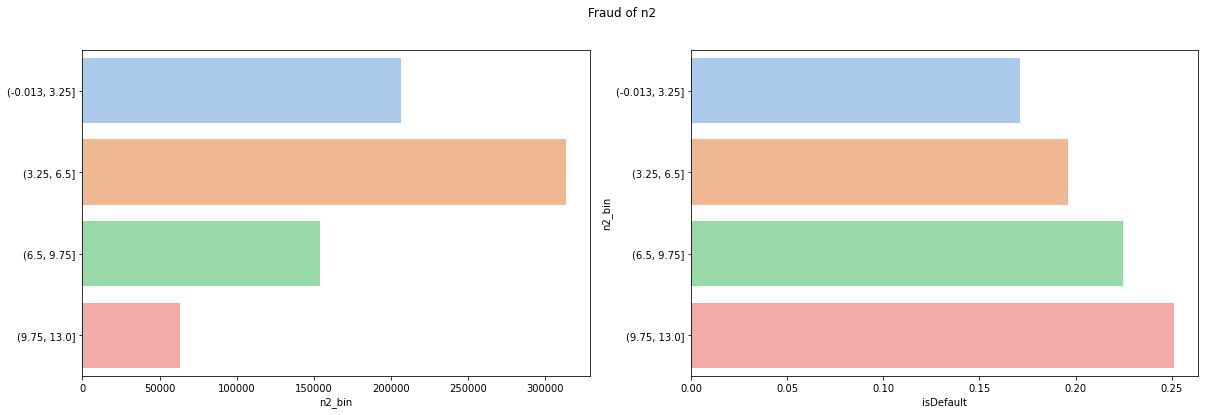

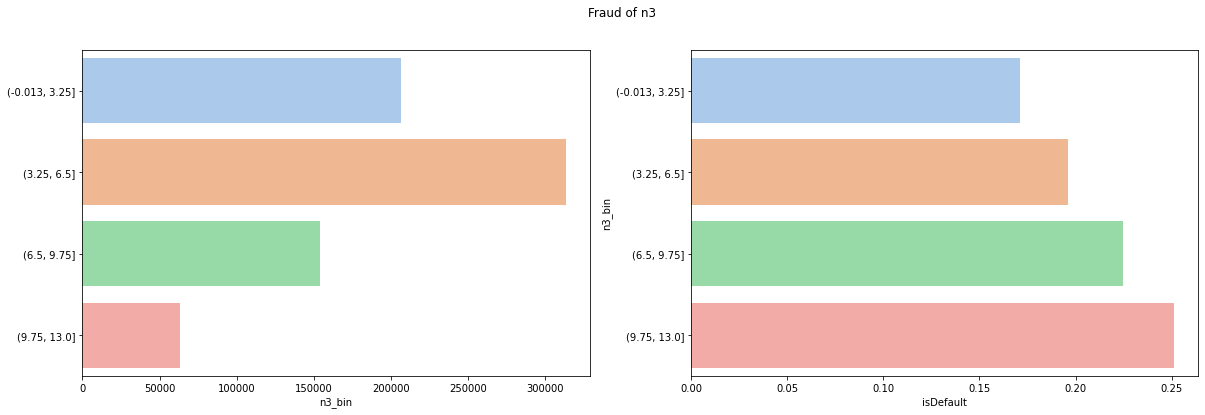

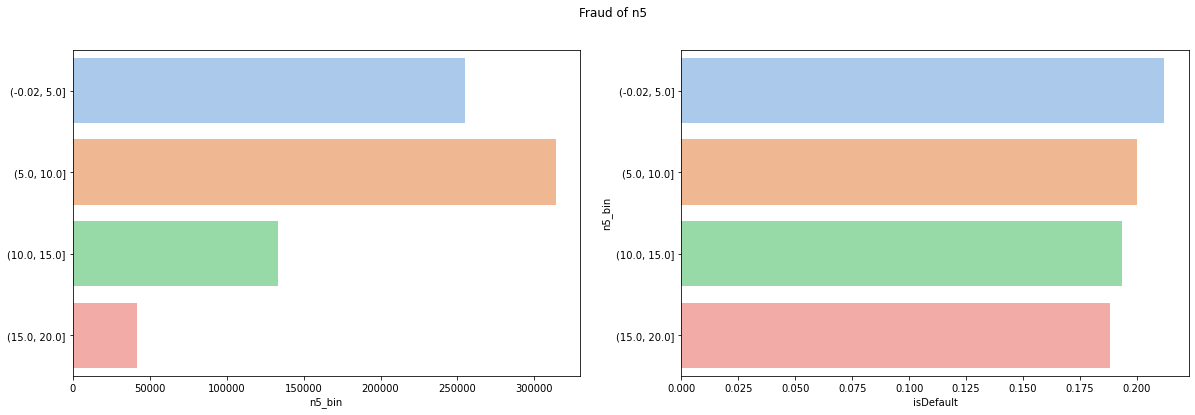

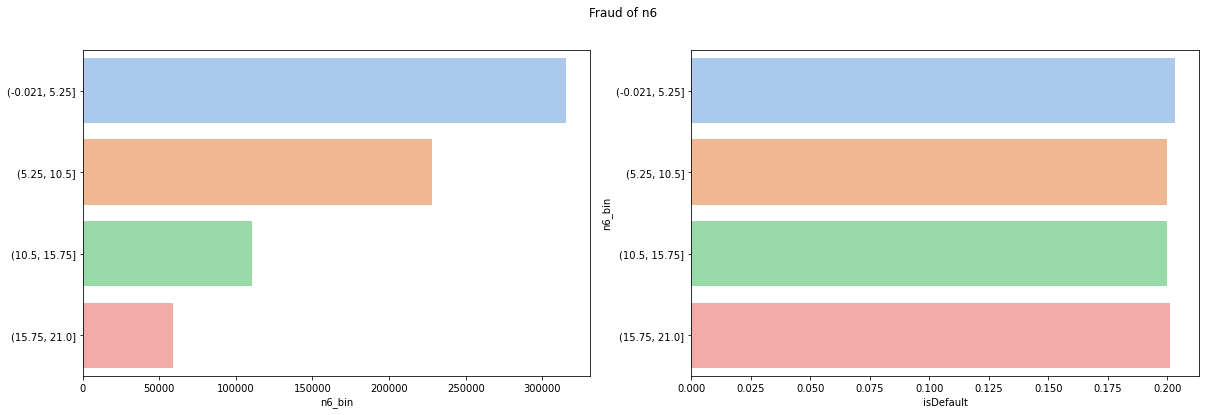

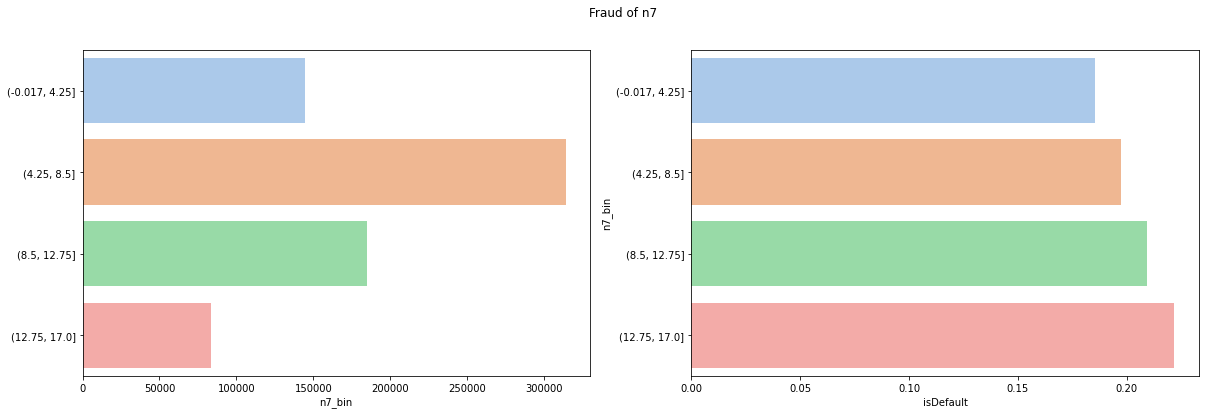

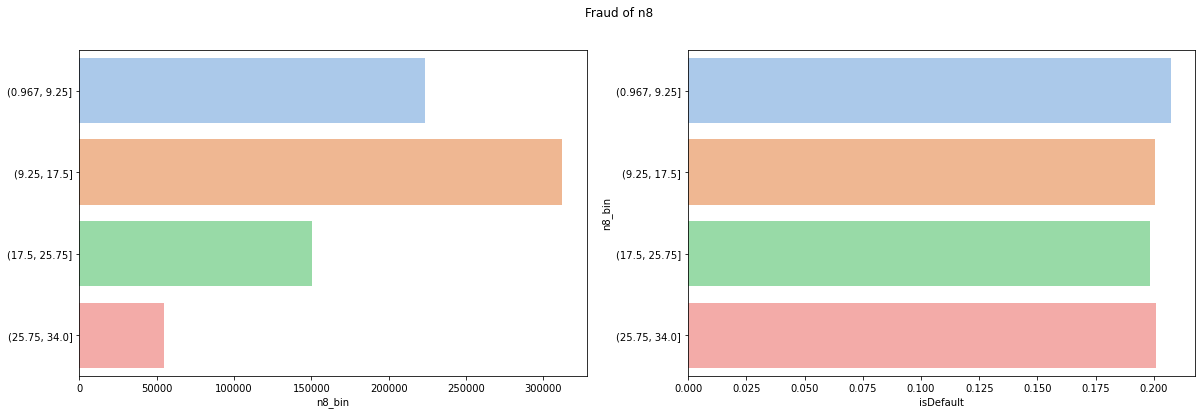

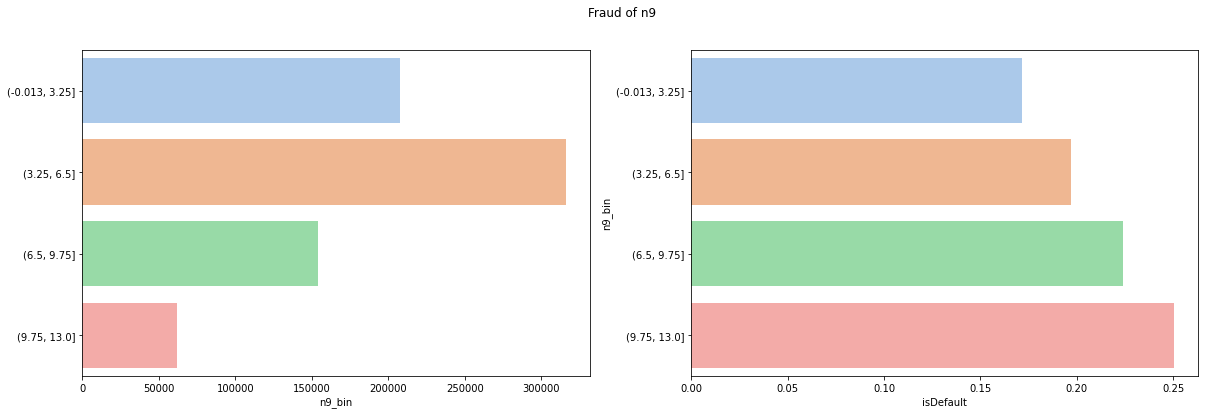

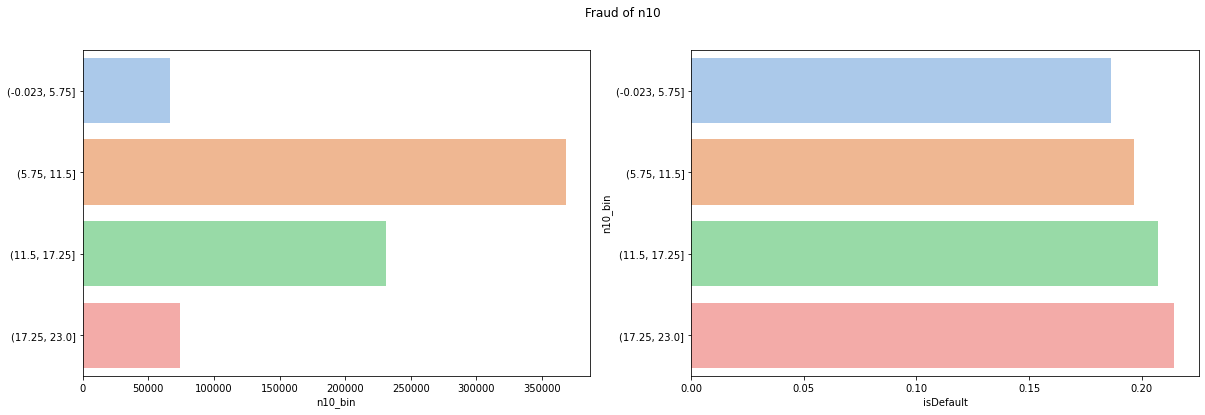

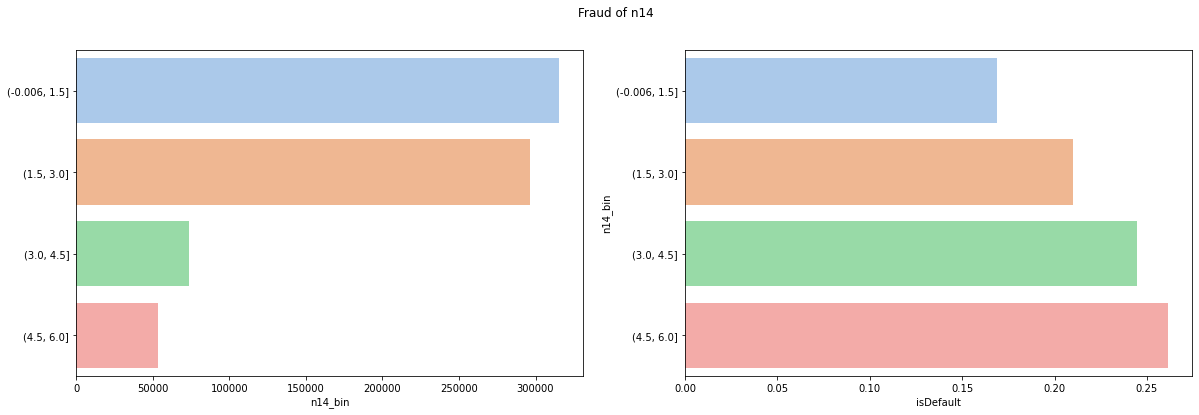

In [2024]:
fea_bin(['totalAcc','openAcc','annualIncome','interestRate','loanAmnt','installment','dti','revolUtil','n2','n3','n5','n6','n7','n8','n9','n10','n14'],bins = 4)

In [2025]:
# def value_counts(col):
#     counts = data_train[col].value_counts(dropna=False).sort_index()
#     describe=data_train[col].describe()
#     return counts, describe
# value_counts('revolUtil')

In [2026]:
for col in numerical_noserial_fea:
    print(col,'\n',data_train[col].value_counts(dropna=False))

term 
 3    606902
5    193098
Name: term, dtype: int64
isDefault 
 0    640390
1    159610
Name: isDefault, dtype: int64
n11 
 0.0    729682
NaN     70318
Name: n11, dtype: int64
n12 
 0.0    757315
NaN     42685
Name: n12, dtype: int64


Text(0.5, 1.0, 'fraud of (term =5)')

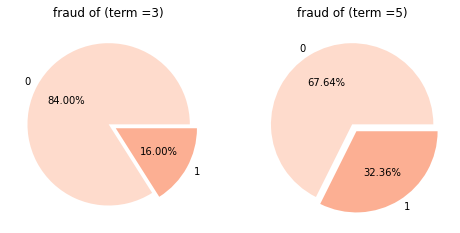

In [2027]:
plt.figure(figsize=(8,6))
plt.subplot(121)
label = data_train[data_train['term']==3]['isDefault'].value_counts().index
plt.pie(data_train[data_train['term']==3]['isDefault'].value_counts(),labels=label,colors = sns.color_palette("Reds"),autopct='%1.2f%%',explode=(0,0.1))
plt.title('fraud of (term =3)')
plt.subplot(122)
label = data_train[data_train['term']==5]['isDefault'].value_counts().index
plt.pie(data_train[data_train['term']==5]['isDefault'].value_counts(),labels=label,colors = sns.color_palette("Reds"),autopct='%1.2f%%',explode=(0,0.1))
plt.title('fraud of (term =5)')

In [2028]:
for col in category_fea:
    print(col,'类型数：',data_train[col].nunique())

id 类型数： 800000
grade 类型数： 7
subGrade 类型数： 35
employmentTitle 类型数： 248684
employmentLength 类型数： 11
homeOwnership 类型数： 6
verificationStatus 类型数： 3
issueDate 类型数： 139
purpose 类型数： 14
postCode 类型数： 933
regionCode 类型数： 51
initialListStatus 类型数： 2
applicationType 类型数： 2
earliesCreditLine 类型数： 720
title 类型数： 39645
policyCode 类型数： 1


In [2029]:
def plot_stats(col):
    
    sub_df = data_train.groupby([col]).mean()
    fig,(ax1,ax2) = plt.subplots(ncols=2, figsize=(12,6))
   
    sns.set_color_codes("pastel")
    sns.barplot(y=data_train[col].value_counts().index, x=data_train[col].value_counts(),ax=ax1)
    sns.barplot(y=sub_df.index, x=sub_df['isDefault'], ax=ax2)
    plt.show()
   

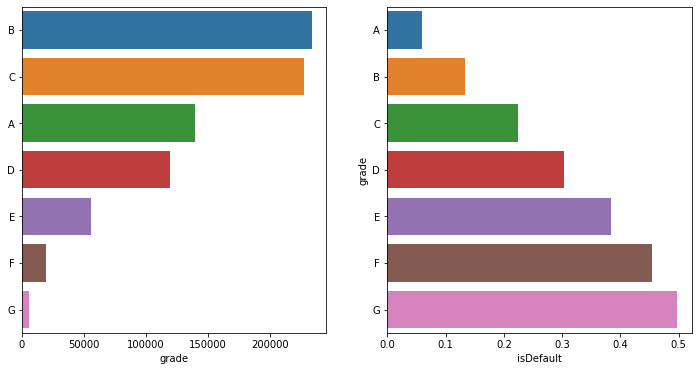

In [2030]:
plot_stats('grade')

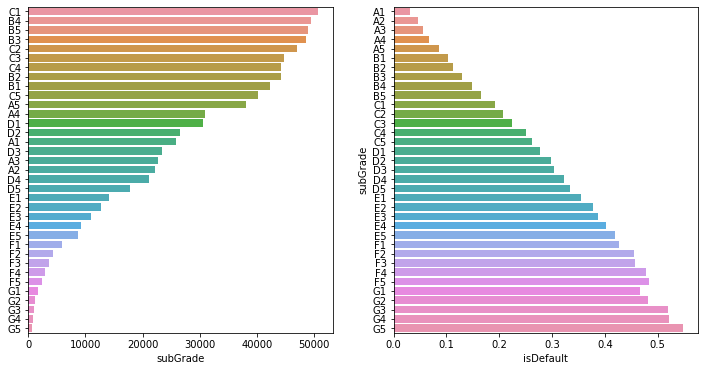

In [2031]:
plot_stats('subGrade')

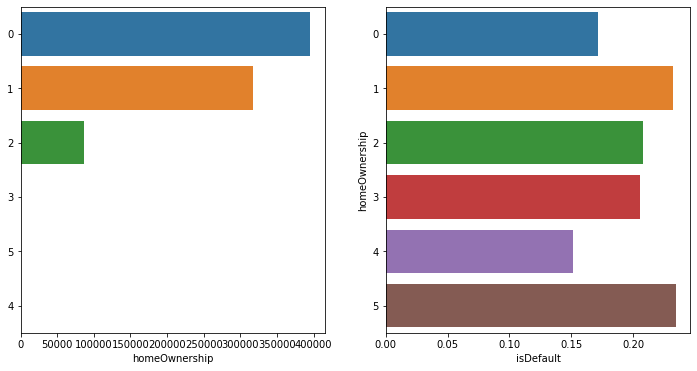

In [2032]:
plot_stats('homeOwnership')

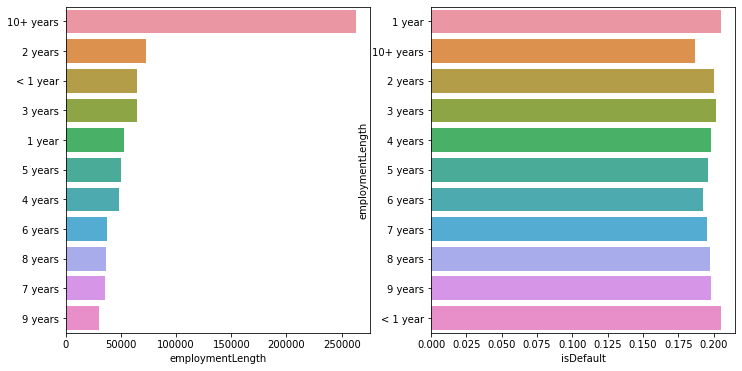

In [2033]:
plot_stats('employmentLength')

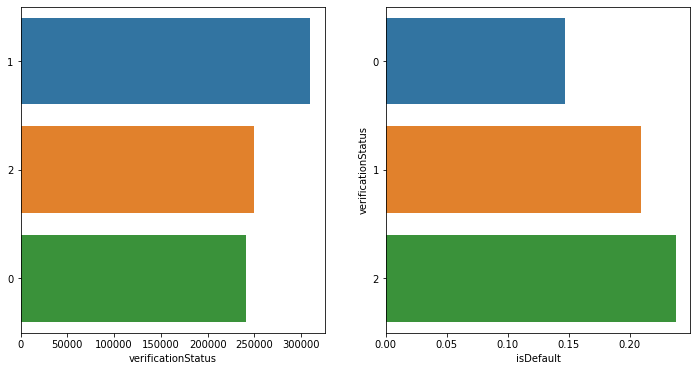

In [2034]:
plot_stats('verificationStatus')

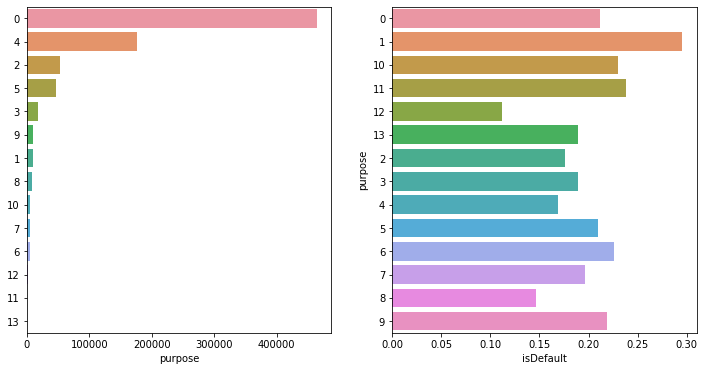

In [2035]:
plot_stats('purpose')

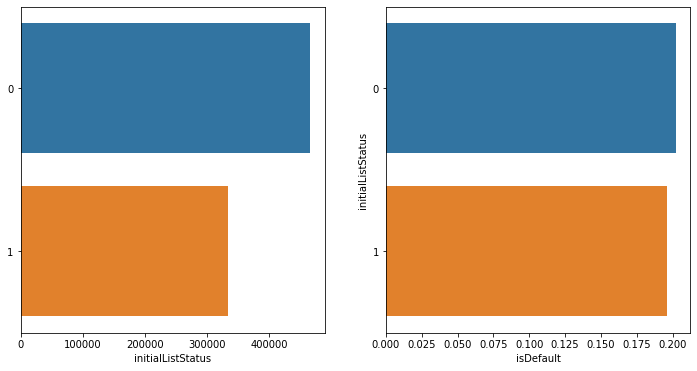

In [2036]:
plot_stats('initialListStatus')

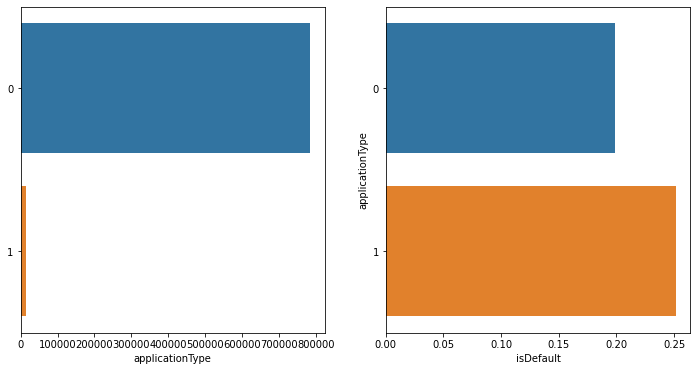

In [2037]:
plot_stats('applicationType')

In [2038]:
class CustomDummifier(TransformerMixin):
    def __init__(self, cols=None):
        self.cols = cols

    def transform(self, X):
        return pd.get_dummies(X, columns=self.cols)

    def fit(self, *_):
        return self


class CustomEncoder(TransformerMixin):
    def __init__(self, col, ordering=None):
        self.col = col
        self.ordering = ordering

    def transform(self, df):
        X = df.copy()
        X[self.col] = X[self.col].map(lambda x: self.ordering.index(x))
        return X

    def fit(self, *_):
        return self



ce = CustomEncoder(col='grade', ordering=['A', 'B', 'C', 'D', 'E', 'F', 'G'])
cd = CustomDummifier(cols=['subGrade', 'homeOwnership', 'verificationStatus', 'purpose', 'applicationType'])
ce.fit(data_train)
cd.fit(data_train)
data_train = ce.transform(data_train)
data_test = ce.transform(data_test)
data_train = cd.transform(data_train)
data_test = cd.transform(data_test)

In [2039]:
data_train

,id,loanAmnt,term,interestRate,installment,grade,employmentTitle,employmentLength,annualIncome,issueDate,isDefault,postCode,regionCode,dti,delinquency_2years,ficoRangeLow,ficoRangeHigh,openAcc,pubRec,pubRecBankruptcies,revolBal,revolUtil,totalAcc,initialListStatus,earliesCreditLine,title,policyCode,n0,n1,n2,n3,n4,n5,n6,n7,n8,n9,n10,n11,n12,n13,n14,subGrade_A1,subGrade_A2,subGrade_A3,subGrade_A4,subGrade_A5,subGrade_B1,subGrade_B2,subGrade_B3,subGrade_B4,subGrade_B5,subGrade_C1,subGrade_C2,subGrade_C3,subGrade_C4,subGrade_C5,subGrade_D1,subGrade_D2,subGrade_D3,subGrade_D4,subGrade_D5,subGrade_E1,subGrade_E2,subGrade_E3,subGrade_E4,subGrade_E5,subGrade_F1,subGrade_F2,subGrade_F3,subGrade_F4,subGrade_F5,subGrade_G1,subGrade_G2,subGrade_G3,subGrade_G4,subGrade_G5,homeOwnership_0,homeOwnership_1,homeOwnership_2,homeOwnership_3,homeOwnership_4,homeOwnership_5,verificationStatus_0,verificationStatus_1,verificationStatus_2,purpose_0,purpose_1,purpose_10,purpose_11,purpose_12,purpose_13,purpose_2,purpose_3,purpose_4,purpose_5,purpose_6,purpose_7,purpose_8,purpose_9,applicationType_0,applicationType_1
0,0,35000.0,5,19.52,917.97,4,320.0,2 years,110000.0,2014-07-01,1,137.0,32,17.05,0.0,730.0,734.0,7.0,0.0,0.0,24178.0,48.9,27.0,0,Aug-2001,1.0,1.0,0.0,2.0,2.0,2.0,4.0,9.0,8.0,4.0,12.0,2.0,7.0,0.0,0.0,0.0,2.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,18000.0,5,18.49,461.90,3,219843.0,5 years,46000.0,2012-08-01,0,156.0,18,27.83,0.0,700.0,704.0,13.0,0.0,0.0,15096.0,38.9,18.0,1,May-2002,1723.0,1.0,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,13.0,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,2,12000.0,5,16.99,298.17,3,31698.0,8 years,74000.0,2015-10-01,0,337.0,14,22.77,0.0,675.0,679.0,11.0,0.0,0.0,4606.0,51.8,27.0,0,May-2006,0.0,1.0,0.0,0.0,3.0,3.0,0.0,0.0,21.0,4.0,5.0,3.0,11.0,0.0,0.0,0.0,4.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,3,11000.0,3,7.26,340.96,0,46854.0,10+ years,118000.0,2015-08-01,0,148.0,11,17.21,0.0,685.0,689.0,9.0,0.0,0.0,9948.0,52.6,28.0,1,May-1999,4.0,1.0,NaN,4.0,6.0,6.0,4.0,16.0,4.0,7.0,21.0,6.0,9.0,0.0,0.0,0.0,1.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
4,4,3000.0,3,12.99,101.07,2,54.0,NaN,29000.0,2016-03-01,0,301.0,21,32.16,0.0,690.0,694.0,12.0,0.0,0.0,2942.0,32.0,27.0,0,Aug-1977,11.0,1.0,NaN,2.0,7.0,7.0,2.0,4.0,9.0,10.0,15.0,7.0,12.0,0.0,0.0,0.0,4.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799995,799995,25000.0,3,14.49,860.41,2,2659.0,7 years,72000.0,2016-07-01,0,242.0,8,19.03,0.0,710.0,714.0,14.0,0.0,0.0,9933.0,46.4,15.0,1,Aug-2011,0.0,1.0,0.0,5.0,10.0,10.0,6.0,6.0,2.0,12.0,13.0,10.0,14.0,0.0,0.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
799996,799996,17000.0,3,7.90,531.94,0,29205.0,10+ years,99000.0,2013-04-01,0,563.0,10,15.72,NaN,720.0,724.0,7.0,0.0,0.0,20472.0,98.4,42.0,0,May-1989,33369.0,1.0,0.0,2.0,2.0,2.0,2.0,15.0,16.0,2.0,19.0,2.0,7.0,0.0,0.0,0.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
799997,799997,6000.0,3,13.33,203.12,2,2582.0,10+ years,65000.0,2015-10-01,1,47.0,17,12.11,NaN,670.0,674.0,5.0,0.0,0.0,6381.0,51.9,36.0,1,Jul-2002,0.0,1.0,NaN

In [2040]:
data_train[numerical_fea].corr()['isDefault']

loanAmnt              0.066667
term                  0.175126
interestRate          0.246029
installment           0.056125
annualIncome         -0.060774
isDefault             1.000000
dti                   0.106574
delinquency_2years         NaN
ficoRangeLow         -0.120056
ficoRangeHigh        -0.120056
openAcc               0.022066
pubRec                     NaN
pubRecBankruptcies         NaN
revolBal             -0.004942
revolUtil             0.059416
totalAcc             -0.015325
n0                         NaN
n1                    0.036034
n2                    0.063377
n3                    0.063377
n4                    0.009190
n5                   -0.020388
n6                   -0.003758
n7                    0.028192
n8                   -0.007681
n9                    0.062069
n10                   0.020816
n11                        NaN
n12                        NaN
n13                        NaN
n14                   0.079806
Name: isDefault, dtype: float64

In [2041]:
data_train = data_train.copy()
data_test = data_test.copy()
for data in [data_train, data_test]:
    data['earliesCreditLine'] = [parse(x) for x in data['earliesCreditLine']]
    data['issueDate'] = pd.to_datetime(data_train['issueDate'], format='%Y-%m-%d')
    data['creditLineDT']=(data['issueDate'] - data['earliesCreditLine']).dt.days
    data['employmentLength'] = data['employmentLength'].replace(
        {'10+ years': '10 years', '< 1 year': '0 year'})
    data['employmentLength'] = data['employmentLength'].map({'0 year':0,'1 year':1,'2 years':2,'3 years':3,'4 years':4,
                                                             '5 years':5,'6 years':6,'7 years':7,'8 years':8,'9 years':9,'10 years':10})
    
    data['credit_income_percent'] = data['loanAmnt']/data['annualIncome']
    data['annuity_income_percent'] = data['installment']/data['annualIncome']

In [2042]:
class CustomCorrelationChooser(TransformerMixin,BaseEstimator):
    def __init__(self,cols_to_keep=[],threshold = None):
        self.cols_to_keep = cols_to_keep 
        self.threshold = threshold
    def transform(self,df):
        X= df.copy()
        self.cols_to_keep = X.columns[X.corr()[X.columns[5]].abs()<self.threshold]
        return df[self.cols_to_keep]
    def fit(self,df,*_):
        
        return self

ccc = CustomCorrelationChooser(threshold=0.02)
ccc.fit_transform(data_train[numerical_fea])

unselect_fea = ccc.cols_to_keep

In [2043]:
unselect_fea

Index(['revolBal', 'totalAcc', 'n4', 'n6', 'n8'], dtype='object')

In [2044]:
drop_fea=['id','employmentTitle','postCode','regionCode','title','policyCode','initialListStatus','issueDate','earliesCreditLine',\
          'revolBal','totalAcc','n0', 'n4', 'n6', 'n8','n11','n12','n13','delinquency_2years','pubRec','pubRecBankruptcies']
data_train = data_train.drop(drop_fea,axis=1)
X_test = data_test.drop(drop_fea,axis=1)


In [2045]:
X_train = data_train.drop(['isDefault'],axis=1)

y_train = data_train['isDefault']

x_train,x_val,y_train,y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=2020)
dtrain = lgb.Dataset(x_train, label=y_train)
dvalid = lgb.Dataset(x_val, label=y_val)


In [2046]:
def lgb_model(num_leaves, max_depth, bagging_fraction, feature_fraction, bagging_freq, min_data_in_leaf,
              min_child_weight, min_split_gain, reg_lambda, reg_alpha):
   
    model_lgb = lgb.LGBMClassifier(boosting_type='gbdt', objective='binary', metric='auc',
                                   learning_rate=0.1, n_estimators=2000,
                                   num_leaves=int(num_leaves), max_depth=int(max_depth),
                                   bagging_fraction=round(bagging_fraction, 2),
                                   feature_fraction=round(feature_fraction, 2),
                                   bagging_freq=int(bagging_freq), min_data_in_leaf=int(min_data_in_leaf),
                                   min_child_weight=min_child_weight, min_split_gain=min_split_gain,
                                   reg_lambda=reg_lambda, reg_alpha=reg_alpha,
                                   n_jobs=8)
    val = cross_val_score(model_lgb, x_train, y_train, cv=5, scoring='roc_auc', error_score='raise').mean()
    return val

bayes_lgb = BayesianOptimization(lgb_model,
                                 {
                                  'num_leaves': (10, 200),
                                  'max_depth': (3, 20),
                                  'bagging_fraction': (0.5, 1.0),
                                  'feature_fraction': (0.5, 1.0),
                                  'bagging_freq': (0, 100),
                                  'min_data_in_leaf': (10, 100),
                                  'min_child_weight': (0, 10), 
                                  'min_split_gain': (0.0, 1.0),
                                  'reg_alpha': (0.0, 10),
                                  'reg_lambda': (0.0, 10)
                                 }
)

bayes_lgb.maximize(n_iter=10)

|   iter    |  target   | baggin... | baggin... | featur... | max_depth | min_ch... | min_da... | min_sp... | num_le... | reg_alpha | reg_la... |
-------------------------------------------------------------------------------------------------------------------------------------------------
[LightGBM] [Warning] feature_fraction is set=0.78, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.78
[LightGBM] [Warning] min_data_in_leaf is set=17, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=17
[LightGBM] [Warning] bagging_fraction is set=0.54, subsample=1.0 will be ignored. Current value: bagging_fraction=0.54
[LightGBM] [Warning] bagging_freq is set=44, subsample_freq=0 will be ignored. Current value: bagging_freq=44
[LightGBM] [Warning] feature_fraction is set=0.78, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.78
[LightGBM] [Warning] min_data_in_leaf is set=17, min_child_samples=20 will be ignored. Current value: min

In [2047]:
print(bayes_lgb.max)

{'target': 0.7223040043481632, 'params': {'bagging_fraction': 0.8597939482969668, 'bagging_freq': 60.56212371997037, 'feature_fraction': 0.5700785473229413, 'max_depth': 5.494432779202622, 'min_child_weight': 8.724380747550162, 'min_data_in_leaf': 99.20691186993946, 'min_split_gain': 0.4877570155837695, 'num_leaves': 198.08323399808936, 'reg_alpha': 9.888414962201038, 'reg_lambda': 6.816219838945311}}


In [2053]:
params = {
            'boosting_type': 'gbdt',
            'objective': 'binary',
            'metric': 'auc',
            'learning_rate': 0.008,
            'num_leaves': 198, 
            'max_depth': 6,
            'min_data_in_leaf':99, 
            'min_child_weight':8.7,
            'bagging_fraction': 0.86, 
            'feature_fraction': 0.57,
            'bagging_freq':61,
            'reg_lambda': 6.8,
            'reg_alpha': 9.9,
            'min_split_gain': 0.49,
            'seed': 2020,
            'silent': True,   
            'n_jobs':-1
}   
model = lgb.train(params, train_set=dtrain, num_boost_round=20000,valid_sets=dvalid, verbose_eval=1000, early_stopping_rounds=200)

val_pred = model.predict(x_val, num_iteration=model.best_iteration)
test_pred = model.predict(X_test, num_iteration=model.best_iteration)

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Info] Number of positive: 128011, number of negative: 511989
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.051185 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2612
[LightGBM] [Info] Number of data points in the train set: 640000, number of used features: 81
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200017 -> initscore=-1.386187
[LightGBM] [Info] Start training from score -1.386187
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 200 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

调参后lightgbm在验证集上的AUC：0.7255784853806744


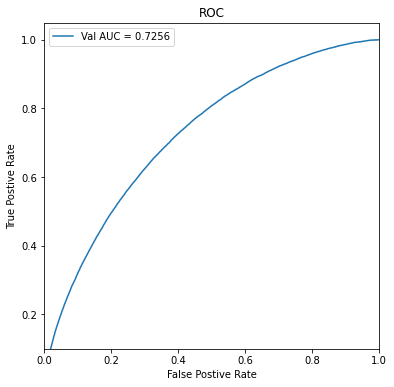

In [2049]:
fpr,tpr,threshold = metrics.roc_curve(y_val,val_pred)
roc_auc = metrics.auc(fpr,tpr)
print('调参后lightgbm在验证集上的AUC：{}'.format(roc_auc))
plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,label='Val AUC = %0.4f'%roc_auc)
plt.xlabel('False Postive Rate')
plt.ylabel('True Postive Rate')
plt.xlim(0,1)
plt.ylim(0.1)
plt.title('ROC')
plt.legend()
plt.show()

In [1869]:
test_pred

array([0.07505169, 0.44269297, 0.44439632, ..., 0.20464336, 0.19323475,
       0.02752706])

<AxesSubplot:title={'center':'gain'}, xlabel='Feature importance', ylabel='Features'>

<Figure size 576x576 with 0 Axes>

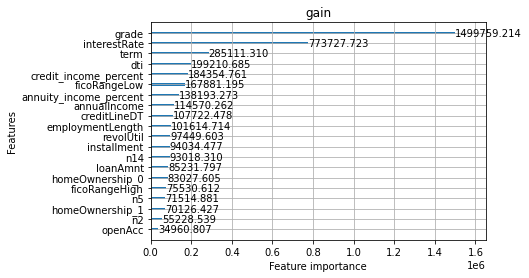

In [1917]:
plt.figure(figsize=(8,8))
plot_importance(model,importance_type='gain',title = 'gain',max_num_features=20)